# FER-2013: CNN Stabilised (Some additional stabilisations have been made to the model)
This notebook trains a CNN on the exact same shared split used by the ANN.

## 1. Imports and Configuration
This section imports libraries and mirrors ANN training settings for fairness.

In [ ]:
# Core utilities
import pathlib
import random

# Numerical work
import numpy as np

# Deep learning framework
import tensorflow as tf

# Plotting
import matplotlib.pyplot as plt

# Splitting + metrics
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight

# -----------------------------
# Reproducibility / Fairness
# -----------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Shared split created by ANN notebook
SPLITS_PATH = pathlib.Path("./fer-2013_splits.npz")

# Same hyperparameters as ANN for fairness
BATCH_SIZE = 64
EPOCHS = 40
LEARNING_RATE = 1e-3

## 2. Load Shared Splits
This section loads the saved FER-2013 train/val/test arrays for a fair test.

In [3]:
# Ensure the shared split exists
if not SPLITS_PATH.exists():
    raise FileNotFoundError(
        "Shared split not found. Run fer-2013-ann.ipynb first to create fer-2013_splits.npz"
    )

# Load shared arrays
splits = np.load(SPLITS_PATH, allow_pickle=True)

X_train, y_train = splits["X_train"], splits["y_train"]
X_val, y_val     = splits["X_val"], splits["y_val"]
X_test, y_test   = splits["X_test"], splits["y_test"]

class_names = splits["class_names"].tolist()
num_classes = len(class_names)

print("Train:", X_train.shape)
print("Val:  ", X_val.shape)
print("Test: ", X_test.shape)
print("Classes:", class_names)

Train: (22967, 48, 48, 1)
Val:   (5742, 48, 48, 1)
Test:  (7178, 48, 48, 1)
Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


## 3. Compute Class Weights (Stabilised)
This section computes the same balanced class weights used in the ANN notebook.

In [4]:
# Compute balanced weights from training labels
# These help reduce the impact of class imbalance in FER-2013 (e.g., 'disgust' is rarer).
cw = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

# Convert to dict for Keras: {class_index: weight}
class_weights = dict(enumerate(cw))

# --- Optional stability tweak ---
# If weights become too large, the model can start over-predicting rare classes.
# Capping keeps weights helpful without letting one class dominate the gradients.
CAP = 3.0
class_weights = {k: float(min(v, CAP)) for k, v in class_weights.items()}

print("Capped class weights:", class_weights)


Capped class weights: {0: 1.0265957446808511, 1: 3.0, 2: 1.0012206286237413, 3: 0.5684338184338185, 4: 0.8260322255790534, 5: 0.849120082815735, 6: 1.2932597556168703}


## 4. Build and Compile Stabilised CNN
This section defines a small CNN with light augmentation for FER-2013 faces.

In [5]:
# --- Stabilised CNN ---
# Aim: improve training stability while keeping the model "teaching-level" and comparable.
# Key changes vs baseline:
# - Batch Normalization after Conv layers (more stable optimisation)
# - Keep model capacity with Flatten (GlobalAveragePooling can underfit on FER-2013)
# - No dropout inside conv blocks (can cause underfitting); keep dropout in dense head
# - Mild augmentation only (avoid making the task harder artificially)

# Light augmentation (applied only during training)
data_augment = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.03),
], name="augment")

def conv_bn_relu_pool(x, filters):
    """One convolutional block: Conv -> BatchNorm -> ReLU -> MaxPool."""
    # use_bias=False is typical when using BatchNorm (BN provides the bias-like shift)
    x = tf.keras.layers.Conv2D(filters, 3, padding="same", use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.MaxPooling2D()(x)
    return x

def build_cnn(num_classes):
    """
    Stabilised CNN for FER-2013 (48x48 grayscale):
    - Convolutions learn local features (eyes, mouth edges, brows).
    - Pooling adds translation invariance.
    - BatchNorm improves training stability.
    """
    inputs = tf.keras.layers.Input(shape=(48, 48, 1), name="input")

    # Apply augmentation in the model graph (Keras disables it automatically at inference)
    x = data_augment(inputs)

    # Feature extractor
    x = conv_bn_relu_pool(x, 32)
    x = conv_bn_relu_pool(x, 64)
    x = conv_bn_relu_pool(x, 128)

    # Keep capacity for this challenging dataset
    x = tf.keras.layers.Flatten()(x)

    # Classifier head
    x = tf.keras.layers.Dense(256, use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.Dropout(0.40)(x)

    outputs = tf.keras.layers.Dense(num_classes, activation="softmax", name="output")(x)
    return tf.keras.Model(inputs, outputs, name="CNN_Stabilised")

# Build CNN
cnn = build_cnn(num_classes)

# Compile with same optimiser/lr as ANN to keep comparison fair
cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cnn.summary()


Model: "CNN_Stabilised"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augment (Sequential)            │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,275,815 (4.87 MB)

 Trainable params: 1,274,855 (4.86 MB)

 Non-trainable params: 960 (3.75 KB)

## 5. Train Stabilised CNN
This section trains the CNN under the same regime as the ANN to isolate architecture effects.

In [6]:
# --- Callbacks ---
# ReduceLROnPlateau: lower learning rate when val_loss plateaus (often boosts generalisation)
# EarlyStopping: stop training once val_loss stops improving (prevents overfitting)
callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True
    )
]

# Train the CNN and store history so we can plot/save learning curves
history = cnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    class_weight=class_weights,
    verbose=1
)



Epoch 1/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 31s 71ms/step - accuracy: 0.3400 - loss: 1.6261 - val_accuracy: 0.3321 - val_loss: 1.6414 - learning_rate: 0.0010
Epoch 2/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 31s 86ms/step - accuracy: 0.4566 - loss: 1.3261 - val_accuracy: 0.4439 - val_loss: 1.4516 - learning_rate: 0.0010
Epoch 3/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 32s 88ms/step - accuracy: 0.4988 - loss: 1.2197 - val_accuracy: 0.4610 - val_loss: 1.3810 - learning_rate: 0.0010
Epoch 4/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 32s 89ms/step - accuracy: 0.5276 - loss: 1.1543 - val_accuracy: 0.5206 - val_loss: 1.2649 - learning_rate: 0.0010
Epoch 5/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 30s 83ms/step - accuracy: 0.5523 - loss: 1.1027 - val_accuracy: 0.5313 - val_loss: 1.2372 - learning_rate: 0.0010
Epoch 6/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 22s 62ms/step - accuracy: 0.5678 - loss: 1.0675 - val_accuracy: 0.3955 - val_loss: 1.4804 - learning_rate: 0.0010
Epoch 7/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 42s 117ms/step - accuracy: 0.5819 - 

## 6. Plot & Save Training Curves
This cell generates the learning curves and saves them as PDFs

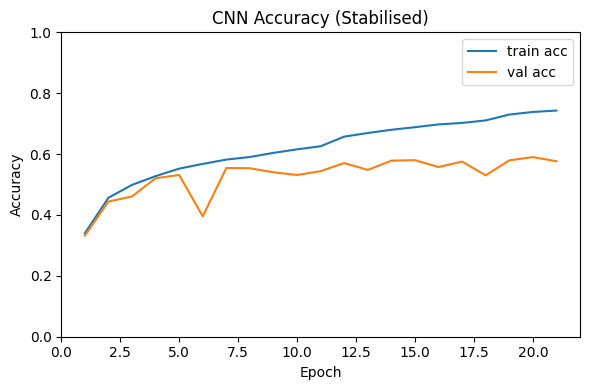

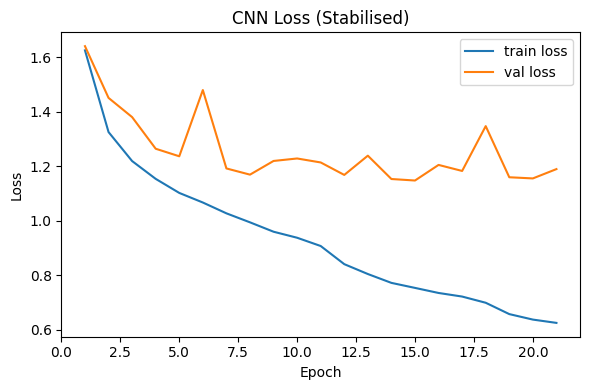

Saved PDFs to:
 - C:\Users\16sim\OneDrive - Bath Spa University\GitHub Repositories\PC\artificial-intelligence-25-26\Assessments\Assessment-2-Machine-Learning\results\plots\cnn\cnn_stabilised_accuracy.pdf
 - C:\Users\16sim\OneDrive - Bath Spa University\GitHub Repositories\PC\artificial-intelligence-25-26\Assessments\Assessment-2-Machine-Learning\results\plots\cnn\cnn_stabilised_loss.pdf


In [7]:
import pathlib
import matplotlib.pyplot as plt

OUT_DIR = pathlib.Path("results/plots/cnn/")
OUT_DIR.mkdir(parents=True, exist_ok=True)

TITLE_PREFIX = "CNN"
FILE_PREFIX = "cnn_stabilised"

# Work out how many epochs actually ran (EarlyStopping may stop early)
epochs_ran = range(1, len(history.history.get("loss", [])) + 1)

# -------- Accuracy plot --------
plt.figure(figsize=(6, 4))

train_acc = history.history.get("accuracy", None)
val_acc = history.history.get("val_accuracy", None)

if train_acc is not None:
    plt.plot(epochs_ran, train_acc, label="train acc")
if val_acc is not None:
    plt.plot(epochs_ran, val_acc, label="val acc")

plt.title(f"{TITLE_PREFIX} Accuracy (Stabilised)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.ylim(0, 1)

acc_pdf_path = OUT_DIR / f"{FILE_PREFIX}_accuracy.pdf"
plt.savefig(acc_pdf_path, format="pdf", bbox_inches="tight")
plt.show()

# -------- Loss plot --------
plt.figure(figsize=(6, 4))

train_loss = history.history.get("loss", None)
val_loss = history.history.get("val_loss", None)

if train_loss is not None:
    plt.plot(epochs_ran, train_loss, label="train loss")
if val_loss is not None:
    plt.plot(epochs_ran, val_loss, label="val loss")

plt.title(f"{TITLE_PREFIX} Loss (Stabilised)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()

loss_pdf_path = OUT_DIR / f"{FILE_PREFIX}_loss.pdf"
plt.savefig(loss_pdf_path, format="pdf", bbox_inches="tight")
plt.show()

print("Saved PDFs to:")
print(" -", acc_pdf_path.resolve())
print(" -", loss_pdf_path.resolve())


## 10. Evaluate Stabilised CNN & Show Confusion Matrices
This section reports test performance and produces two confusion matrices for later comparison.

CNN Test Accuracy: 0.5897

Classification Report (CNN Stabilised):
              precision    recall  f1-score   support

       angry       0.46      0.55      0.50       958
     disgust       0.57      0.54      0.55       111
        fear       0.55      0.27      0.36      1024
       happy       0.77      0.81      0.79      1774
     neutral       0.48      0.67      0.56      1233
         sad       0.49      0.42      0.45      1247
    surprise       0.74      0.71      0.72       831

    accuracy                           0.59      7178
   macro avg       0.58      0.57      0.56      7178
weighted avg       0.59      0.59      0.58      7178



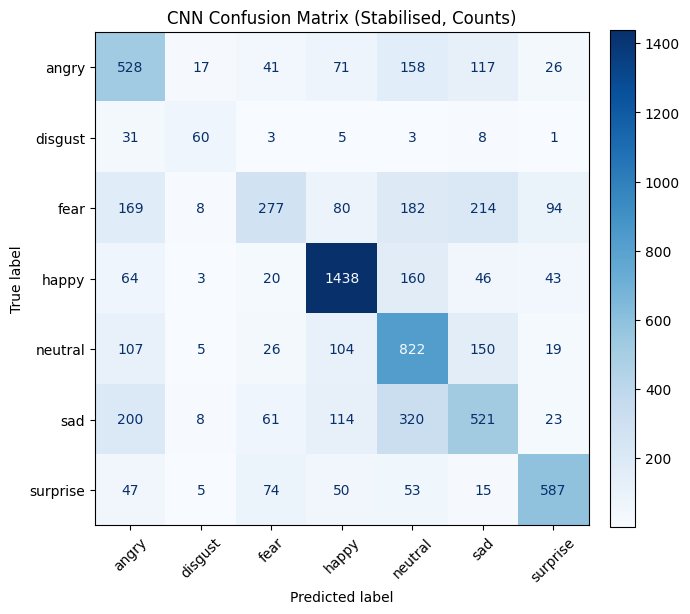

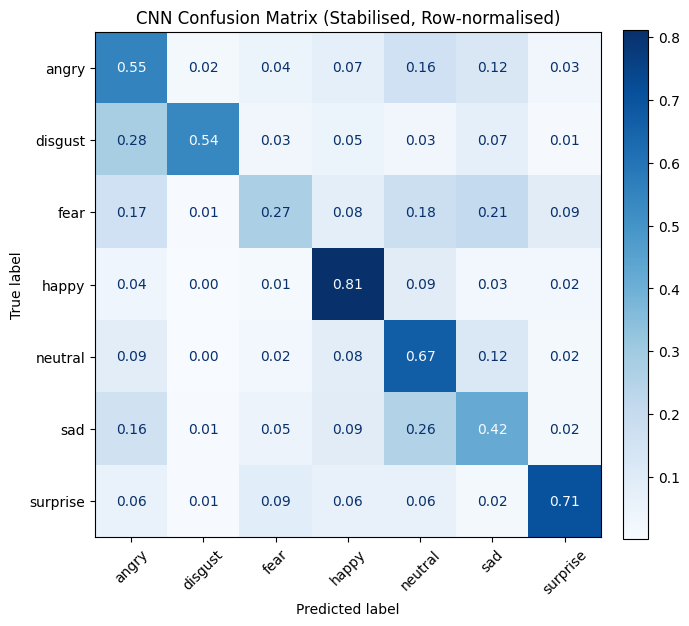


Saved confusion matrix PDFs to:
 - C:\Users\16sim\OneDrive - Bath Spa University\GitHub Repositories\PC\artificial-intelligence-25-26\Assessments\Assessment-2-Machine-Learning\results\confusion-matrices\cnn\cnn_stabilised_cm_counts.pdf
 - C:\Users\16sim\OneDrive - Bath Spa University\GitHub Repositories\PC\artificial-intelligence-25-26\Assessments\Assessment-2-Machine-Learning\results\confusion-matrices\cnn\cnn_stabilised_cm_row_normalised.pdf


In [ ]:
# --- Evaluate CNN + Confusion Matrices (Counts + Row-normalised) + Save as PDFs ---
# This cell:
# 1) Evaluates on the held-out test set
# 2) Generates predictions + classification report
# 3) Plots confusion matrix (counts)
# 4) Plots confusion matrix (row-normalised)
# 5) Saves both confusion matrices as PDFs

# -----------------------------
# 1) Evaluate on held-out test set
# -----------------------------
# The test set is never used during training/validation.
test_loss, test_acc = cnn.evaluate(X_test, y_test, verbose=0)
print(f"CNN Test Accuracy: {test_acc:.4f}")

# -----------------------------
# 2) Predict labels (argmax over softmax probabilities)
# -----------------------------
y_pred = np.argmax(cnn.predict(X_test, verbose=0), axis=1)

# -----------------------------
# 3) Classification report (precision/recall/F1)
# -----------------------------
print("\nClassification Report (CNN Stabilised):")
print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

# -----------------------------
# 4) Prepare output folder and filenames
# -----------------------------
OUT_DIR = pathlib.Path("results/confusion-matrices/cnn/")
OUT_DIR.mkdir(parents=True, exist_ok=True)

TITLE_PREFIX = "CNN"
FILE_PREFIX = "cnn_stabilised"

# -----------------------------
# 5) Confusion Matrix (Counts)
# -----------------------------
cm_counts = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 7))

# Plot the matrix WITHOUT a colourbar (we'll add our own so it matches height)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_counts, display_labels=class_names)
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, values_format="d", colorbar=False)

# Manually add a colourbar that is tied to the matrix axis (same height)
im = ax.images[0]  # the heatmap image
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

ax.set_title(f"{TITLE_PREFIX} Confusion Matrix (Stabilised, Counts)")
fig.tight_layout()

counts_pdf_path = OUT_DIR / f"{FILE_PREFIX}_cm_counts.pdf"
fig.savefig(counts_pdf_path, format="pdf", bbox_inches="tight")
plt.show()
plt.close(fig)

# -----------------------------
# 6) Confusion Matrix (Row-normalised)
# -----------------------------
# Each row sums to 1.00, so you can compare per-class behaviour fairly.
cm_row = confusion_matrix(y_test, y_pred, normalize="true")

fig, ax = plt.subplots(figsize=(7, 7))

# Plot WITHOUT colourbar first
disp = ConfusionMatrixDisplay(confusion_matrix=cm_row, display_labels=class_names)
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, values_format=".2f", colorbar=False)

# Add matching-height colourbar
im = ax.images[0]
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

ax.set_title(f"{TITLE_PREFIX} Confusion Matrix (Stabilised, Row-normalised)")
fig.tight_layout()

row_pdf_path = OUT_DIR / f"{FILE_PREFIX}_cm_row_normalised.pdf"
fig.savefig(row_pdf_path, format="pdf", bbox_inches="tight")
plt.show()
plt.close(fig)

# -----------------------------
# 7) Confirm saved files
# -----------------------------
print("\nSaved confusion matrix PDFs to:")
print(" -", counts_pdf_path.resolve())
print(" -", row_pdf_path.resolve())
